# Predicting Health Insurance Costs Using Machine Learning

## 1: Exploratory Data Analysis

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loading the data
data = pd.read_csv("data/raw/insurance.csv")
data.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [5]:
# checking data info
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   str    
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   str    
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   str    
 8   region         1337 non-null   str    
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 104.8 KB


In [7]:
# setup for pandas and seaborn
pd.set_option("display.float_format", "{:.2f}".format)
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

In [8]:
# checking for duplicates
data.duplicated().sum()

np.int64(0)

In [9]:
# checking for missing values
data.isnull().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [10]:
# dropping the missing values
data.dropna(inplace=True)

In [12]:
#  lets confirm that the missing values have been dropped
data.isnull().sum().sum()

np.int64(0)

In [13]:
# data summary statistics
data.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1332.00,1332.00,1332.00,1332.00,1332.00,1332.00
mean,674.47,38.09,30.66,94.19,1.10,13325.25
std,384.70,11.11,6.12,11.45,1.21,12109.62
min,1.00,18.00,16.00,80.00,0.00,1121.87
25%,341.75,29.00,26.20,86.00,0.00,4760.16
50%,674.50,38.00,30.35,92.00,1.00,9412.97
75%,1007.25,47.00,34.73,99.00,2.00,16781.33
max,1340.00,60.00,53.10,140.00,5.00,63770.43


In [14]:
# data shape
data.shape

(1332, 10)

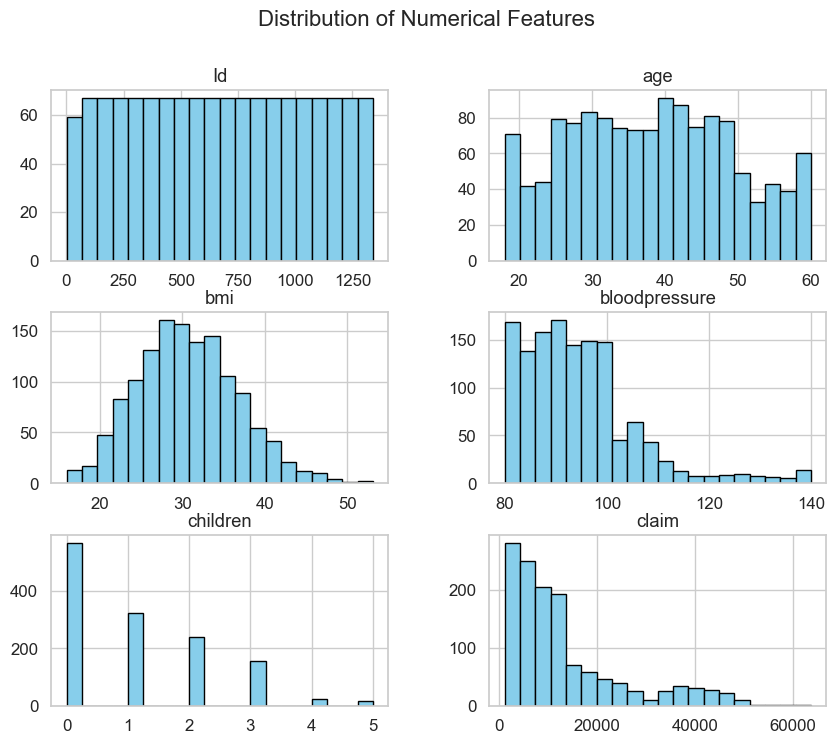

In [16]:
# numerical features distribution
numerical_features = data.select_dtypes(include=["int64", "float64"]).columns
data[numerical_features].hist(figsize=(10, 8), bins=20, color="skyblue", edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

C:\Users\Ericksollo\AppData\Local\Temp\ipykernel_2456\3907835582.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2")
C:\Users\Ericksollo\AppData\Local\Temp\ipykernel_2456\3907835582.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2")
C:\Users\Ericksollo\AppData\Local\Temp\ipykernel_2456\3907835582.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2")
C:\Users\Ericksollo\AppData\Local\Temp\ipykernel_2456\3907835582.py:7: FutureWarning: 



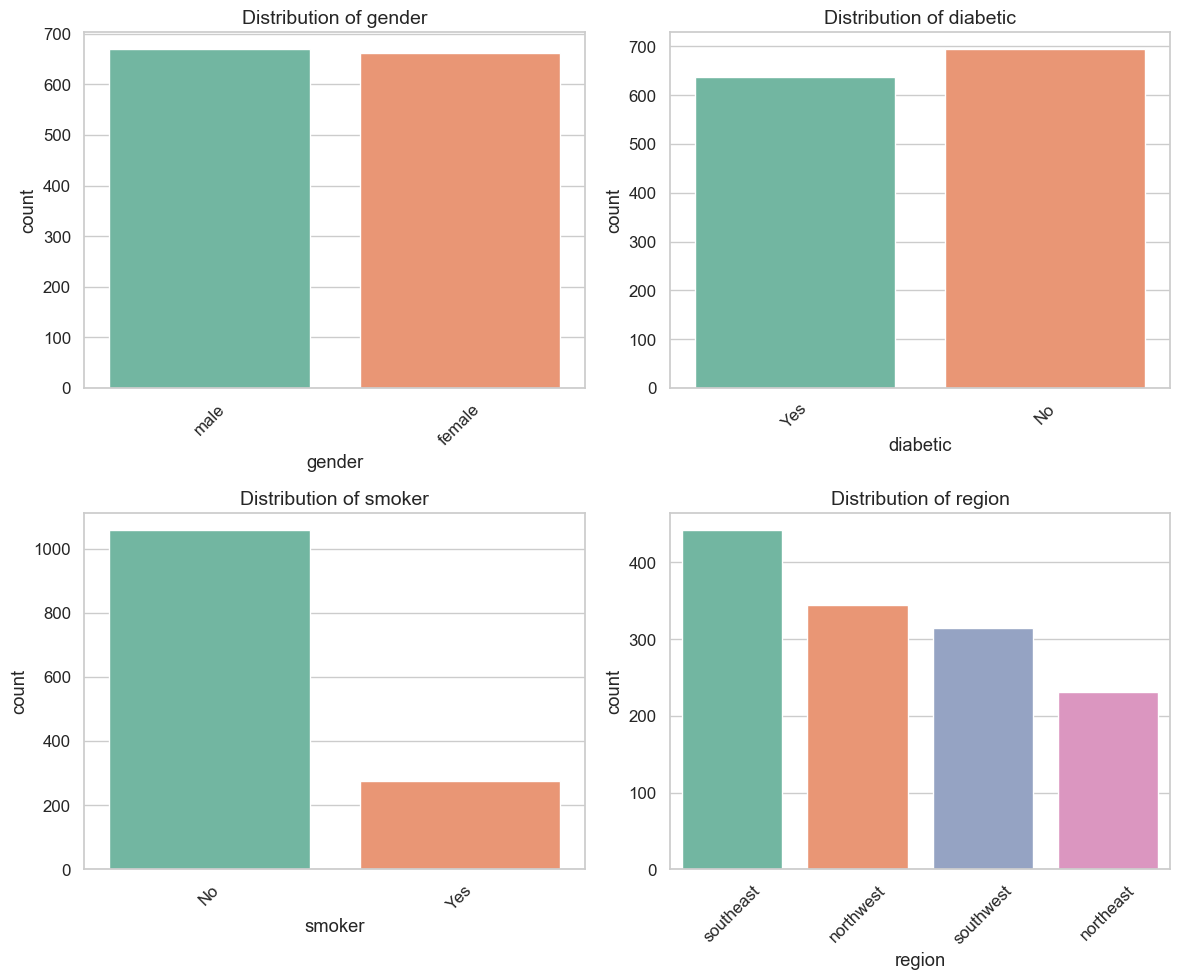

In [25]:
# categorical features distribution
categorical_features = [data.select_dtypes(include=["str"]).columns]

plt.figure(figsize=(12, 10))
for i, col in enumerate(categorical_features[0]):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data=data, x=col, palette="Set2")
    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# average claim amount by gender and smoker status
data.groupby(['gender', 'smoker'])['claim'].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

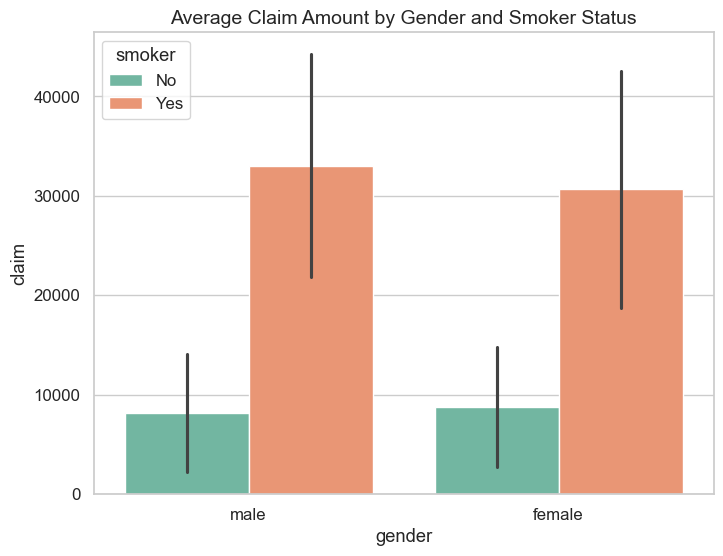

In [ ]:
# bar plot of claim amount by smoker status
plt.figure(figsize=(8, 6))
sns.barplot(data=data, x="gender", y="claim", palette="Set2", hue= 'smoker', estimator= "mean", errorbar='sd')
plt.title("Average Claim Amount by Gender and Smoker Status", fontsize=14)
plt.show()


In [33]:
# average claim by region and diabetic

pivot_region_diabetic = data.groupby(['region', 'diabetic'])['claim'].mean().unstack()
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


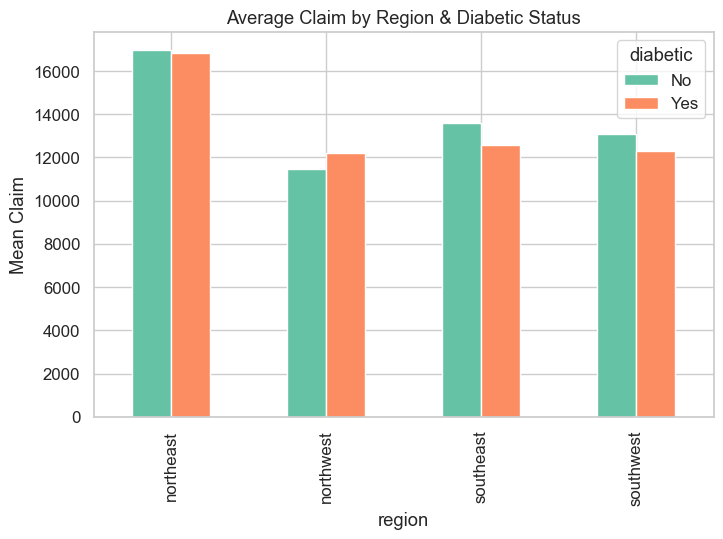

In [34]:
# plot pivot_region_diabetic
pivot_region_diabetic.plot( kind="bar", figsize= (8,5))
plt.title("Average Claim by Region & Diabetic Status")
plt.ylabel("Mean Claim")
plt.show()


In [36]:
# pivot table by average smoker and region

pivot_table = pd.pivot_table(data, values='claim', index='region', columns ='smoker', aggfunc = 'mean')
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [37]:
# average claim by diabetic and children count
pivot_table = pd.pivot_table(data, values='claim', index ='children', columns = 'diabetic', aggfunc='mean')
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [41]:
# dropping Id column in feature list
numerical_features = [col for col in data.select_dtypes(include='number').columns if col != 'Id']
numerical_features

['age', 'bmi', 'bloodpressure', 'children', 'claim']

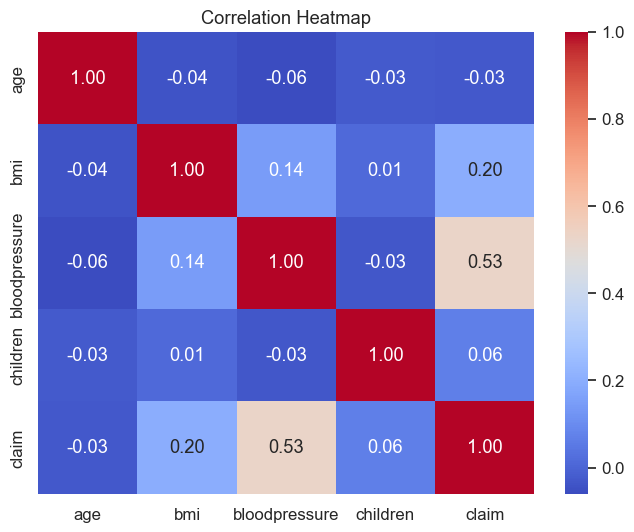

In [43]:
# corr heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data[numerical_features].corr(), annot = True, cmap ='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

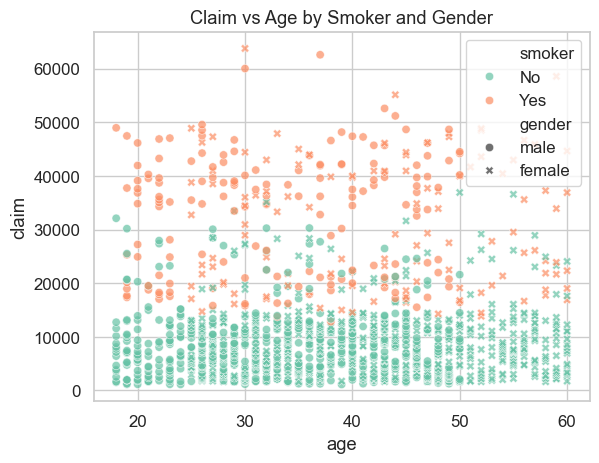

In [44]:
# relation analysis
sns.scatterplot(data= data, x ="age", y="claim", hue ="smoker", style = "gender", alpha=0.7)
plt.title('Claim vs Age by Smoker and Gender')
plt.show()

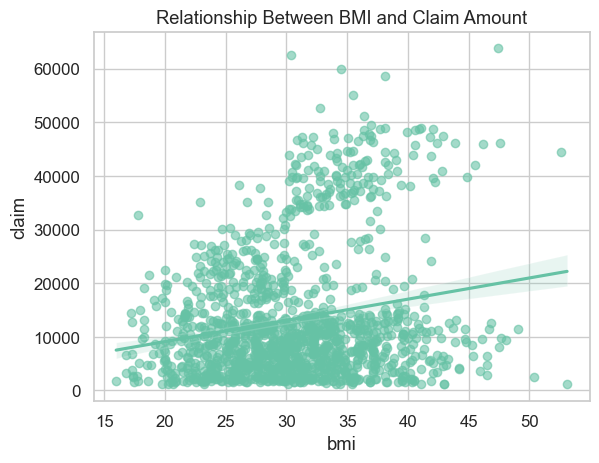

In [46]:
# relation analysis
sns.regplot(data=data, x = "bmi", y="claim", scatter_kws={"alpha": 0.6})
plt.title("Relationship Between BMI and Claim Amount")
plt.show()

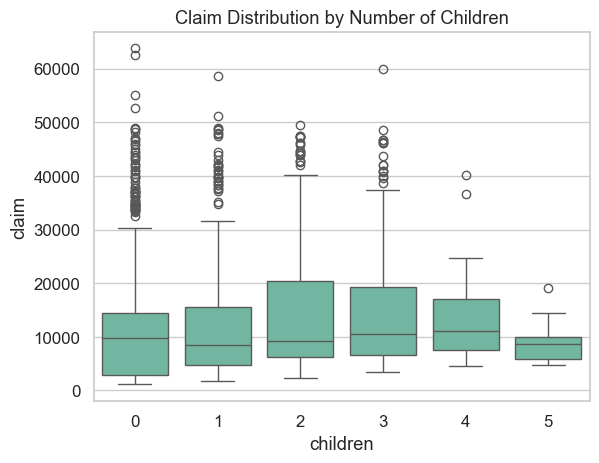

In [47]:
# realtiion analysis
sns.boxplot(data=data, x= "children", y="claim")
plt.title("Claim Distribution by Number of Children")
plt.show()

In [ ]:
# New age bands feature
data['age_group'] = pd.cut(data['age'], bins = [0,13,30,45,60,100], labels=["<13", "18-30", "31-45", "46-60", '60+'])

In [49]:
data

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,31-45
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,18-30
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,31-45


In [50]:
# age groups value counts
data["age_group"].value_counts()

age_group
31-45    553
18-30    396
46-60    383
<13        0
60+        0
Name: count, dtype: int64

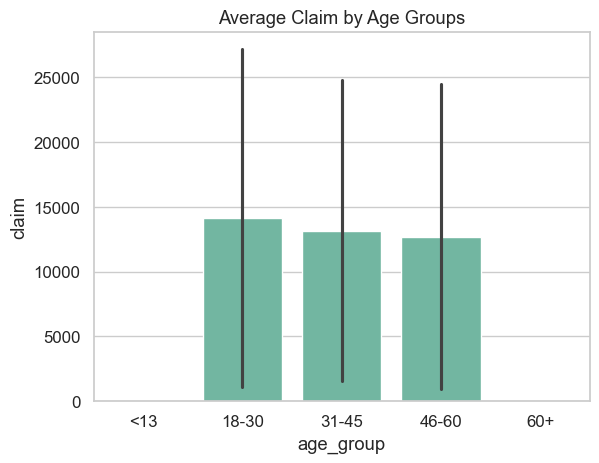

In [52]:
# visualising age groups value counts
sns.barplot(data=data, x="age_group",y="claim", estimator= "mean", errorbar="sd")
plt.title("Average Claim by Age Groups")
plt.show()

In [56]:
# New bmi_category feature
data['bmi_category'] = pd.cut(data['bmi'], bins = [0, 18.5, 24.9, 29.9,100], labels=['Underweight',"Normal","Overweight", "Obese" ])


In [57]:
# bmi_category value counts
data["bmi_category"].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

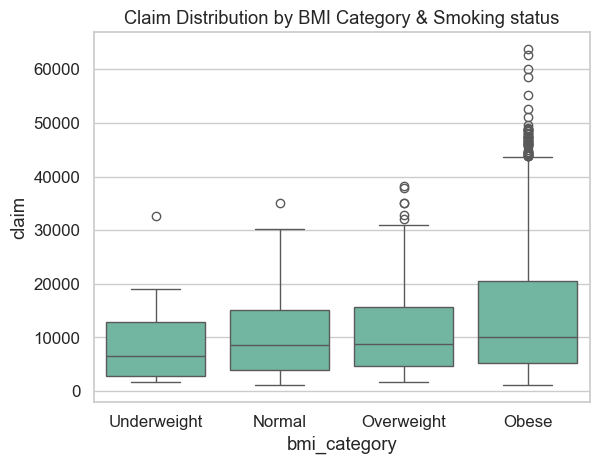

In [63]:
# bmi_category value counts visualisation

sns.boxplot(data=data, x="bmi_category",y="claim")
plt.title('Claim Distribution by BMI Category & Smoking status')
plt.show()

In [64]:
#
region_status = data.groupby('region').agg(
    smoker_rate = ("smoker", lambda x: (x=="Yes").mean() * 100),
    mean_claim= ("claim", "mean")
).reset_index()

In [65]:
region_status

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


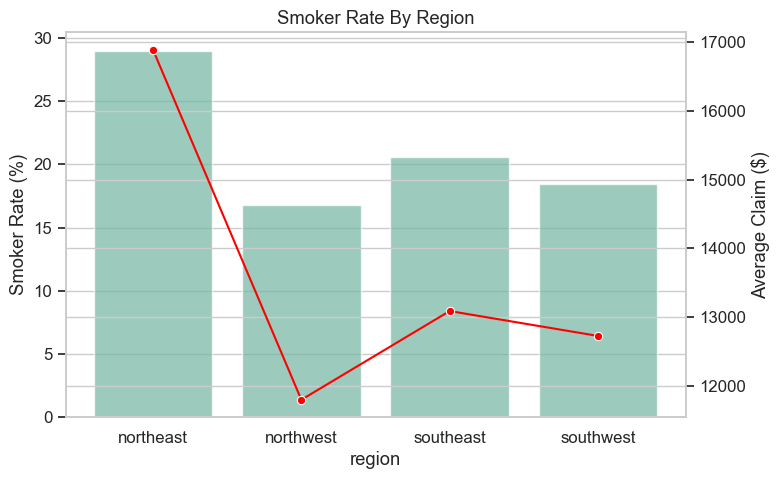

In [67]:
# visualising region_status
fig, ax1 = plt.subplots(figsize=(8,5))
sns.barplot(data = region_status, x ="region", y="smoker_rate", ax=ax1, alpha= 0.7)
ax2 = ax1.twinx()
sns.lineplot(data = region_status, x="region", y="mean_claim", ax=ax2, color="red", marker= "o")
ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Average Claim ($)")
plt.title("Smoker Rate By Region")
plt.show()


## 2: Data Preprocessing & Feature Engineering

In [72]:
# import Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [75]:
# load columns to drop unneccessaary columns
data.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='str')

In [76]:
# Defining X and y
X= data.drop(columns=['Id', 'age_group', 'bmi_category', 'claim'])
y = data['claim']

In [79]:
# load X
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region
0,39.00,male,23.20,91,Yes,0,No,southeast
1,24.00,male,30.10,87,No,0,No,southeast
7,19.00,male,41.10,100,No,0,No,northwest
8,20.00,male,43.00,86,No,0,No,northwest
9,30.00,male,53.10,97,No,0,No,northwest
...,...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes,northwest
1336,59.00,female,38.10,120,No,1,Yes,northeast
1337,30.00,male,34.50,91,Yes,3,Yes,northwest
1338,37.00,male,30.40,106,No,0,Yes,southeast


In [85]:
# loading categorical columns of X
categorical_features = X.select_dtypes(include='str').columns.tolist()
categorical_features

['gender', 'diabetic', 'smoker', 'region']

In [86]:
# encoding categorical columns
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

    joblib.dump(le, f"models/LabelEncoder_{col}.pkl")



In [88]:
# loading encoded X
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region
0,39.00,1,23.20,91,1,0,0,2
1,24.00,1,30.10,87,0,0,0,2
7,19.00,1,41.10,100,0,0,0,1
8,20.00,1,43.00,86,0,0,0,1
9,30.00,1,53.10,97,0,0,0,1
...,...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1,1
1336,59.00,0,38.10,120,0,1,1,0
1337,30.00,1,34.50,91,1,3,1,1
1338,37.00,1,30.40,106,0,0,1,2


In [89]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder(),
 'region': LabelEncoder()}

In [90]:
# Splitting data into train and test 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [93]:
# scale the numerical features
numerical_features = ['age', 'bmi', 'bloodpressure', 'children']

scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.fit_transform(X_test[numerical_features])

In [94]:
# saving the scaler

joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [95]:
# shapes of train and test

print(X_train.shape, y_train.shape)

print(X_test.shape, y_test.shape)

(1065, 8) (1065,)
(267, 8) (267,)


## 3: Training Machine Learning Models

In [98]:
# import libraries
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


In [99]:
# defining model evaluation function

def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae =mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {"R2" : r2, "MAE" : mae, "RMSE" : rmse}

In [100]:
# Dictionary for model results
results = {}

In [102]:
# Linear Regression model training

lr = LinearRegression()
lr.fit(X_train, y_train)
results['Linear Regression'] = evaluate_model(lr, X_train, X_test, y_train,y_test)
print("Linear Regression model trained")

Linear Regression model trained


In [105]:
# Polynomial Regression models training

best_poly_model = None
best_poly_score =-np.inf

for degree in [2,3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)

    score = poly_lr.score(X_test_poly, y_test)

    if score > best_poly_score:

        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

degree, poly, poly_lr = best_poly_model

results[f"Polynomial Regression (deg = {degree})"] = evaluate_model(poly_lr, poly.fit_transform(X_train), poly.transform(X_test), y_train, y_test)

print("Polynomial Regression models are trained")


Polynomial Regression models are trained


In [106]:
# Random Forest Regression training

rf = RandomForestRegressor()

rf_params = {
    "n_estimators" : [100, 200],
    "max_depth" : [None, 10, 20],
    "min_samples_split" : [2,5],
    "min_samples_leaf" : [1,2]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring="r2", n_jobs =-1, verbose=0)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluate_model(best_rf, X_train, X_test, y_train, y_test)

print("Random Forest training is completed, best paremeters:", rf_grid.best_params_)



Random Forest training is completed, best paremeters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [107]:
# Support Vector Regression training

svr = SVR()

svr_params = {
    "kernel" : ["rbf", "poly", "linear"],
    "C" : [1,10,50],
    "epsilon" : [0.1, 0.2, 0.5],
    "degree" : [2,3]
}

svr_grid = GridSearchCV(svr, svr_params, cv=3, scoring="r2", n_jobs=-1, verbose=0)
svr_grid.fit(X_train, y_train)

best_svr = svr_grid.best_estimator_

results["SVR"] = evaluate_model(best_svr, X_train, X_test, y_train, y_test)

print("SVR training is completed, best parameters:", svr_grid.best_params_)

SVR training is completed, best parameters: {'C': 50, 'degree': 2, 'epsilon': 0.5, 'kernel': 'linear'}


In [108]:
# XGBoost training

xgb = XGBRegressor(objective="reg:squarederror")

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample" : [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring="r2", n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

results["XGBoost"] = evaluate_model(best_xgb, X_train, X_test, y_train, y_test)

print("XGBoost training is completed, best parameters:",xgb_grid.best_params_ )


XGBoost training is completed, best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [111]:
# compare models results
results_df = pd.DataFrame(results).T.sort_values(by= "R2", ascending=False)
results_df

,R2,MAE,RMSE
XGBoost,0.75,4094.47,5691.14
Random Forest,0.75,4178.03,5767.81
Polynomial Regression (deg = 2),0.74,4381.56,5801.92
Linear Regression,0.68,4913.58,6455.13
SVR,0.52,5651.17,7944.53


In [112]:
# models

models= {
    "Linear Regression": lr,
    "Polynomial Regression": poly_lr,
    "Random Forest" : best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb
}

In [114]:
# model with best r2 score

best_r2 = results_df["R2"].max()
best_r2

np.float64(0.7541336058395851)

In [115]:
# top model

top_model = results_df[results_df["R2"] ==best_r2]
top_model

,R2,MAE,RMSE
XGBoost,0.75,4094.47,5691.14


In [ ]:
# best model
best_model = models[top_model.index[0]]
best_model

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [118]:
# saving the best model

joblib.dump(best_model, "models/best_model.pkl")

print(f"Best model selected: {top_model.index[0]}")

Best model selected: XGBoost
